In [41]:
# Importlari adim adim ve sureleriyle yukle
import time
_cell_start = time.time()

_t = time.time()
import torch
print(f"[OK] torch ({time.time() - _t:.2f}s)")

_t = time.time()
import torch.nn as nn
print(f"[OK] torch.nn ({time.time() - _t:.2f}s)")

_t = time.time()
import torch.optim as optim
print(f"[OK] torch.optim ({time.time() - _t:.2f}s)")

_t = time.time()
from torch.utils.data import DataLoader, WeightedRandomSampler
print(f"[OK] torch.utils.data ({time.time() - _t:.2f}s)")

_t = time.time()
from torchvision import datasets, transforms
print(f"[OK] torchvision ({time.time() - _t:.2f}s)")

_t = time.time()
import timm  # PyTorch Image Models
print(f"[OK] timm ({time.time() - _t:.2f}s)")

_t = time.time()
import os
print(f"[OK] os ({time.time() - _t:.2f}s)")

_t = time.time()
import matplotlib.pyplot as plt
print(f"[OK] matplotlib.pyplot ({time.time() - _t:.2f}s)")

_t = time.time()
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score
print(f"[OK] sklearn.metrics ({time.time() - _t:.2f}s)")

_t = time.time()
import seaborn as sns
print(f"[OK] seaborn ({time.time() - _t:.2f}s)")

_t = time.time()
import pandas as pd
print(f"[OK] pandas ({time.time() - _t:.2f}s)")

_t = time.time()
import numpy as np
print(f"[OK] numpy ({time.time() - _t:.2f}s)")

# Uyarilari gizlemek icin (istege bagli)
import warnings
warnings.filterwarnings("ignore")

print(f"1. hucre importlari tamamlandi. Toplam sure: {time.time() - _cell_start:.2f}s")

[OK] torch (0.00s)
[OK] torch.nn (0.00s)
[OK] torch.optim (0.00s)
[OK] torch.utils.data (0.00s)
[OK] torchvision (0.00s)
[OK] timm (0.00s)
[OK] os (0.00s)
[OK] matplotlib.pyplot (0.00s)
[OK] sklearn.metrics (0.00s)
[OK] seaborn (0.00s)
[OK] pandas (0.00s)
[OK] numpy (0.00s)
1. hucre importlari tamamlandi. Toplam sure: 0.00s


In [52]:
# --- KONFIGURASYON (MobileNetV3 Large) ---
# MobileNetV3 Large Modeli (timm kodu: mobilenetv3_large_100)
MODEL_NAME = 'mobilenetv3_large_100'

# Deney Adi
EXPERIMENT_NAME = "MobileNetV3Large_Baseline_MediumLarge_Run1"

# Hiperparametreler
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 2e-4
NUM_CLASSES = 8
DROPOUT_RATE = 0.5

# Duzenlilestirme ve egitim kararliligi
WEIGHT_DECAY = 5e-4
LABEL_SMOOTHING = 0.1
WARMUP_EPOCHS = 3
EARLY_STOPPING_PATIENCE = 5
USE_CLASS_WEIGHTED_LOSS = False
IMBALANCE_RATIO_THRESHOLD = 1.5
FORCE_WEIGHTED_SAMPLER = False

# Notebook + Windows icin daha stabil DataLoader ayari
NUM_WORKERS = 0 if os.name == 'nt' else 4

# Proje kok yolunu calisma dizininden bagimsiz bul
cwd = os.getcwd()
if os.path.isdir(os.path.join(cwd, "data", "prepared-data")):
    PROJECT_ROOT = cwd
elif os.path.isdir(os.path.join(cwd, "..", "data", "prepared-data")):
    PROJECT_ROOT = os.path.abspath(os.path.join(cwd, ".."))
else:
    PROJECT_ROOT = cwd

# --- DOSYA YOLLARI ---
DATA_DIR = os.path.join(PROJECT_ROOT, "data", "prepared-data")

# Calistirma etiketleri (hiperparametrelere gore otomatik dosya isimlendirme)
dropout_tag = f"dropout{int(round(DROPOUT_RATE * 10)):02d}"
ls_tag = f"ls{int(round(LABEL_SMOOTHING * 100)):02d}"
wd_tag = f"wd{str(WEIGHT_DECAY).replace('.', 'p').replace('-', 'm')}"
lr_tag = f"lr{LEARNING_RATE:g}".replace(".", "p")
sampler_tag = "smpON" if FORCE_WEIGHTED_SAMPLER else "smpOFF"
RUN_TAG = f"{dropout_tag}_{ls_tag}_{wd_tag}_bs{BATCH_SIZE}_ep{EPOCHS}_{lr_tag}_{sampler_tag}"
RUN_NAME = f"{EXPERIMENT_NAME}_{RUN_TAG}"

# Sonuclarin kaydedilecegi yer
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "models", "pytorch", RUN_NAME)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# En iyi model dosya yolu
BEST_MODEL_PATH = os.path.join(OUTPUT_DIR, f"best_model_{MODEL_NAME}_{RUN_TAG}.pth")

# Cihaz Kontrolu
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"CWD: {cwd}")
print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"Cihaz: {DEVICE}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")
print(f"Model: {MODEL_NAME}")
print(f"Run Tag: {RUN_TAG}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"Kayit Yeri: {OUTPUT_DIR}")
print(f"Best Model Yolu: {BEST_MODEL_PATH}")
print(f"NUM_WORKERS: {NUM_WORKERS}")

CWD: c:\Users\mehme\OneDrive\Masaüstü\Gastroenterology-CNN-Comparison\MobileNetV3
PROJECT_ROOT: c:\Users\mehme\OneDrive\Masaüstü\Gastroenterology-CNN-Comparison
Cihaz: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
Model: mobilenetv3_large_100
Run Tag: dropout05_ls10_wd0p001_bs32_ep50_lr0p0003_smpOFF
DATA_DIR: c:\Users\mehme\OneDrive\Masaüstü\Gastroenterology-CNN-Comparison\data\prepared-data
Kayit Yeri: c:\Users\mehme\OneDrive\Masaüstü\Gastroenterology-CNN-Comparison\models\pytorch\MobileNetV3Large_Baseline_MediumLarge_Run1_dropout05_ls10_wd0p001_bs32_ep50_lr0p0003_smpOFF
Best Model Yolu: c:\Users\mehme\OneDrive\Masaüstü\Gastroenterology-CNN-Comparison\models\pytorch\MobileNetV3Large_Baseline_MediumLarge_Run1_dropout05_ls10_wd0p001_bs32_ep50_lr0p0003_smpOFF\best_model_mobilenetv3_large_100_dropout05_ls10_wd0p001_bs32_ep50_lr0p0003_smpOFF.pth
NUM_WORKERS: 0


In [53]:
# ImageNet Normalize Degerleri
mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

# Veri Donusumleri (ana veri uzerinden: augmentation yok)
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])
}

# Datasetleri Olustur
image_datasets = {x: datasets.ImageFolder(os.path.join(DATA_DIR, x), data_transforms[x])
                  for x in ['train', 'val', 'test']}

# Sinif dengesizligi analizi
train_targets = np.array(image_datasets['train'].targets)
class_sample_counts = np.bincount(train_targets, minlength=NUM_CLASSES)
imbalance_ratio = class_sample_counts.max() / max(1, class_sample_counts.min())
AUTO_USE_WEIGHTED_SAMPLER = imbalance_ratio >= IMBALANCE_RATIO_THRESHOLD
USE_WEIGHTED_SAMPLER = FORCE_WEIGHTED_SAMPLER or AUTO_USE_WEIGHTED_SAMPLER

class_weight_values = class_sample_counts.sum() / (NUM_CLASSES * np.clip(class_sample_counts, 1, None))
CLASS_WEIGHTS_TENSOR = torch.tensor(class_weight_values, dtype=torch.float32)

train_sampler = None
if USE_WEIGHTED_SAMPLER:
    sample_weights = class_weight_values[train_targets]
    train_sampler = WeightedRandomSampler(
        weights=torch.tensor(sample_weights, dtype=torch.double),
        num_samples=len(sample_weights),
        replacement=True
    )

# DataLoaderlari Olustur
dataloaders = {
    'train': DataLoader(
        image_datasets['train'],
        batch_size=BATCH_SIZE,
        shuffle=(train_sampler is None),
        sampler=train_sampler,
        num_workers=NUM_WORKERS,
        pin_memory=True
    ),
    'val': DataLoader(image_datasets['val'], batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True),
    'test': DataLoader(image_datasets['test'], batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
class_names = image_datasets['train'].classes

# Basit veri sizintisi kontrolu: train-val/test ayni dosya adlari
train_files = set(os.path.basename(p).lower() for p, _ in image_datasets['train'].samples)
val_files = set(os.path.basename(p).lower() for p, _ in image_datasets['val'].samples)
test_files = set(os.path.basename(p).lower() for p, _ in image_datasets['test'].samples)
overlap_train_val = train_files.intersection(val_files)
overlap_train_test = train_files.intersection(test_files)

leak_report_path = os.path.join(OUTPUT_DIR, f"leakage_check_{RUN_TAG}.txt")
with open(leak_report_path, "w", encoding="utf-8") as f:
    f.write(f"Train-Val same filename count: {len(overlap_train_val)}\n")
    f.write(f"Train-Test same filename count: {len(overlap_train_test)}\n")
    if overlap_train_val:
        f.write("Sample Train-Val overlaps:\n")
        f.write("\n".join(list(sorted(overlap_train_val))[:20]))
        f.write("\n")
    if overlap_train_test:
        f.write("Sample Train-Test overlaps:\n")
        f.write("\n".join(list(sorted(overlap_train_test))[:20]))
        f.write("\n")

print(f"Siniflar: {class_names}")
print(f"Egitim Verisi: {dataset_sizes['train']}")
print(f"Validasyon Verisi: {dataset_sizes['val']}")
print(f"Test Verisi: {dataset_sizes['test']}")
print(f"Sinif sayimlari (train): {class_sample_counts.tolist()}")
print(f"Imbalance ratio (max/min): {imbalance_ratio:.2f}")
print(f"Weighted sampler otomatik onerisi: {AUTO_USE_WEIGHTED_SAMPLER}")
print(f"Weighted sampler zorla acik: {FORCE_WEIGHTED_SAMPLER}")
print(f"Weighted sampler aktif: {USE_WEIGHTED_SAMPLER}")
print(f"Class-weighted loss aktif: {USE_CLASS_WEIGHTED_LOSS}")
print(f"NUM_WORKERS: {NUM_WORKERS}")
print(f"Leakage raporu: {leak_report_path}")

Siniflar: ['dyed-lifted-polyps', 'dyed-resection-margins', 'esophagitis', 'normal-cecum', 'normal-pylorus', 'normal-z-line', 'polyps', 'ulcerative-colitis']
Egitim Verisi: 5592
Validasyon Verisi: 1200
Test Verisi: 1208
Sinif sayimlari (train): [699, 699, 699, 699, 699, 699, 699, 699]
Imbalance ratio (max/min): 1.00
Weighted sampler otomatik onerisi: False
Weighted sampler zorla acik: False
Weighted sampler aktif: False
Class-weighted loss aktif: False
NUM_WORKERS: 0
Leakage raporu: c:\Users\mehme\OneDrive\Masaüstü\Gastroenterology-CNN-Comparison\models\pytorch\MobileNetV3Large_Baseline_MediumLarge_Run1_dropout05_ls10_wd0p001_bs32_ep50_lr0p0003_smpOFF\leakage_check_dropout05_ls10_wd0p001_bs32_ep50_lr0p0003_smpOFF.txt


In [54]:
def create_model():
    print(f"Model indiriliyor: {MODEL_NAME}...")
    model = timm.create_model(
        MODEL_NAME,
        pretrained=True,
        num_classes=NUM_CLASSES,
        drop_rate=DROPOUT_RATE
    )
    return model

model = create_model()
model = model.to(DEVICE)

# Kayıp Fonksiyonu ve Optimizer (duzenlilestirme guclendirildi)
loss_weight = CLASS_WEIGHTS_TENSOR.to(DEVICE) if USE_CLASS_WEIGHTED_LOSS else None
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING, weight=loss_weight)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Warmup + CosineAnnealing benzeri plan (LambdaLR)
def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return float(epoch + 1) / float(max(1, WARMUP_EPOCHS))
    progress = (epoch - WARMUP_EPOCHS) / float(max(1, EPOCHS - WARMUP_EPOCHS))
    progress = min(max(progress, 0.0), 1.0)
    return 0.5 * (1.0 + np.cos(np.pi * progress))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

print("Model GPU'ya yuklendi ve egitime hazir.")
print(f"AdamW + weight_decay={WEIGHT_DECAY}, label_smoothing={LABEL_SMOOTHING}")

Model indiriliyor: mobilenetv3_large_100...
Model GPU'ya yuklendi ve egitime hazir.
AdamW + weight_decay=0.001, label_smoothing=0.1


In [55]:
def train_model(model, criterion, optimizer, scheduler, num_epochs):
    required_globals = [
        "dataloaders", "dataset_sizes", "OUTPUT_DIR", "DEVICE", "BEST_MODEL_PATH", "EARLY_STOPPING_PATIENCE"
    ]
    missing = [name for name in required_globals if name not in globals()]
    if missing:
        raise RuntimeError(
            f"Eksik degisken(ler): {missing}. Lutfen once veri ve konfigurasyon hucrelerini calistirin."
        )

    # Kayit klasorunun var oldugunu garanti et
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    os.makedirs(os.path.dirname(BEST_MODEL_PATH), exist_ok=True)

    since = time.time()
    best_acc = 0.0
    best_val_loss = float('inf')
    epochs_without_improvement = 0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(DEVICE)
                labels = labels.to(DEVICE)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())

            if phase == 'val':
                if epoch_acc > best_acc:
                    best_acc = epoch_acc

                if epoch_loss < best_val_loss:
                    best_val_loss = epoch_loss
                    epochs_without_improvement = 0
                    torch.save(model.state_dict(), BEST_MODEL_PATH)
                    print(f"En Iyi Model (val loss: {best_val_loss:.4f}) -> {BEST_MODEL_PATH}")
                else:
                    epochs_without_improvement += 1
                    print(
                        f"Val loss iyilesmedi: {epochs_without_improvement}/{EARLY_STOPPING_PATIENCE}"
                    )

        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']
        history['lr'].append(current_lr)
        print(f"Guncel LR: {current_lr:.8f}")

        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            print("Erken durdurma tetiklendi.")
            break

    time_elapsed = time.time() - since
    print(f'\nEgitim Tamamlandi: {time_elapsed // 60:.0f}dk {time_elapsed % 60:.0f}sn')
    print(f'En Iyi Validasyon Dogrulugu: {best_acc:.4f}')
    print(f'En Dusuk Validasyon Kaybi: {best_val_loss:.4f}')

    model.load_state_dict(torch.load(BEST_MODEL_PATH))
    return model, history

In [56]:
# --- BASLAT ---
required_vars = ["model", "criterion", "optimizer", "scheduler", "train_model"]
missing = [name for name in required_vars if name not in globals()]
if missing:
    raise RuntimeError(
        f"Eksik degisken(ler): {missing}. Lutfen once model/egitim hazirlik hucrelerini calistirin."
    )

num_epochs = int(globals().get("EPOCHS", 50))
model, history = train_model(model, criterion, optimizer, scheduler, num_epochs=num_epochs)

Epoch 1/50
----------
train Loss: 1.8830 Acc: 0.6060
val Loss: 1.0903 Acc: 0.8433
En Iyi Model (val loss: 1.0903) -> c:\Users\mehme\OneDrive\Masaüstü\Gastroenterology-CNN-Comparison\models\pytorch\MobileNetV3Large_Baseline_MediumLarge_Run1_dropout05_ls10_wd0p001_bs32_ep50_lr0p0003_smpOFF\best_model_mobilenetv3_large_100_dropout05_ls10_wd0p001_bs32_ep50_lr0p0003_smpOFF.pth
Guncel LR: 0.00020000
Epoch 2/50
----------
train Loss: 1.1749 Acc: 0.7906
val Loss: 0.8577 Acc: 0.8825
En Iyi Model (val loss: 0.8577) -> c:\Users\mehme\OneDrive\Masaüstü\Gastroenterology-CNN-Comparison\models\pytorch\MobileNetV3Large_Baseline_MediumLarge_Run1_dropout05_ls10_wd0p001_bs32_ep50_lr0p0003_smpOFF\best_model_mobilenetv3_large_100_dropout05_ls10_wd0p001_bs32_ep50_lr0p0003_smpOFF.pth
Guncel LR: 0.00030000
Epoch 3/50
----------
train Loss: 0.9198 Acc: 0.8562
val Loss: 0.7874 Acc: 0.9025
En Iyi Model (val loss: 0.7874) -> c:\Users\mehme\OneDrive\Masaüstü\Gastroenterology-CNN-Comparison\models\pytorch\MobileNet

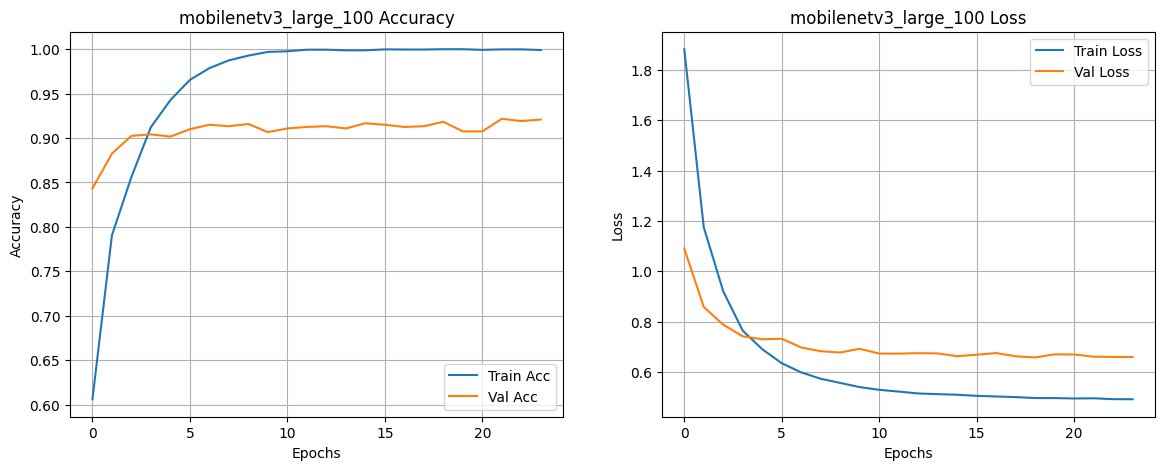

Grafikler kaydedildi: c:\Users\mehme\OneDrive\Masaüstü\Gastroenterology-CNN-Comparison\outputs\training_graph_mobilenetv3_large_100_dropout05_ls10_wd0p001_bs32_ep50_lr0p0003_smpOFF.png


In [ ]:
plt.figure(figsize=(14, 5))

# Dogruluk Grafigi
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title(f'{MODEL_NAME} Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Kayip Grafigi
plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title(f'{MODEL_NAME} Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Kaydet ve Goster
PLOT_OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'outputs', MODEL_NAME, 'plots')
os.makedirs(PLOT_OUTPUT_DIR, exist_ok=True)
plot_path = os.path.join(PLOT_OUTPUT_DIR, f'training_graph_{MODEL_NAME}_{RUN_TAG}.png')
plt.savefig(plot_path)
plt.show()
print(f"Grafikler kaydedildi: {plot_path}")


TEST SETI DEGERLENDIRMESI

Siniflandirma Raporu:
                        precision    recall  f1-score   support

    dyed-lifted-polyps     0.8931    0.9404    0.9161       151
dyed-resection-margins     0.9441    0.8940    0.9184       151
           esophagitis     0.8012    0.8543    0.8269       151
          normal-cecum     0.9677    0.9934    0.9804       151
        normal-pylorus     0.9869    1.0000    0.9934       151
         normal-z-line     0.8451    0.7947    0.8191       151
                polyps     0.9658    0.9338    0.9495       151
    ulcerative-colitis     0.9463    0.9338    0.9400       151

              accuracy                         0.9180      1208
             macro avg     0.9188    0.9180    0.9180      1208
          weighted avg     0.9188    0.9180    0.9180      1208

Macro F1: 0.9180
Class recall degerleri:
  dyed-lifted-polyps: 0.9404
  dyed-resection-margins: 0.8940
  esophagitis: 0.8543
  normal-cecum: 0.9934
  normal-pylorus: 1.0000
  norm

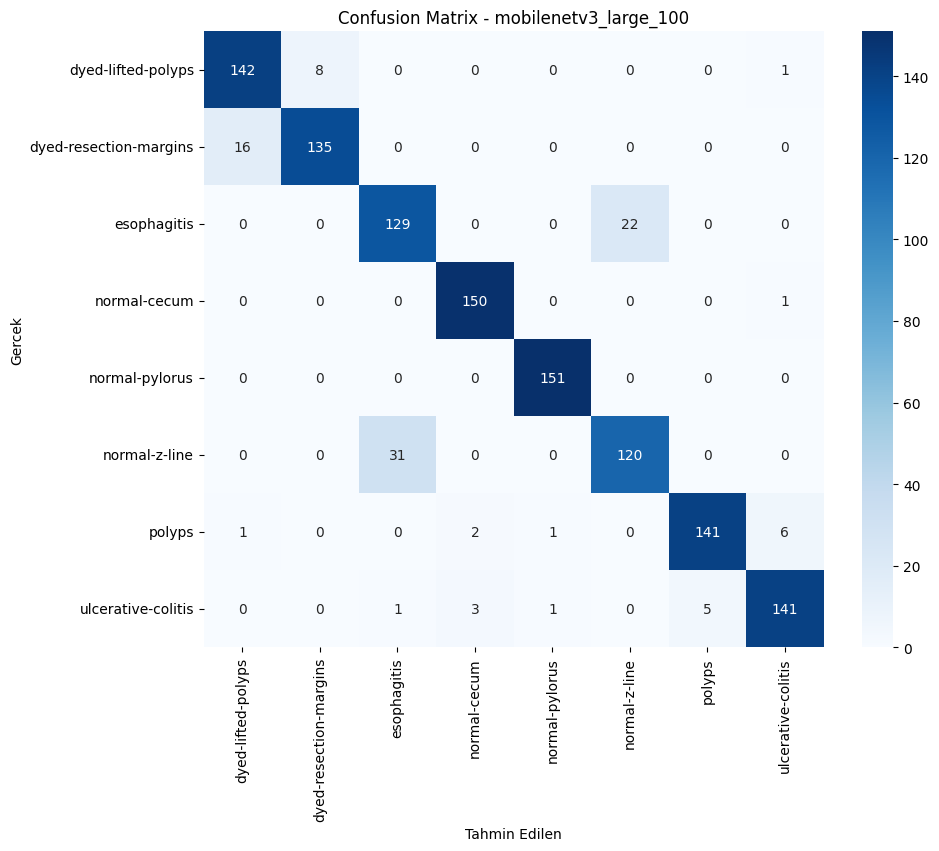

Confusion matrix kaydedildi: c:\Users\mehme\OneDrive\Masaüstü\Gastroenterology-CNN-Comparison\outputs\confusion_matrix_mobilenetv3_large_100_dropout05_ls10_wd0p001_bs32_ep50_lr0p0003_smpOFF.png
esophagitis <-> normal-z-line toplam hata: 53
dyed-lifted-polyps <-> dyed-resection-margins toplam hata: 24
Ablation sonuclari kaydedildi: c:\Users\mehme\OneDrive\Masaüstü\Gastroenterology-CNN-Comparison\outputs\ablation_results_mobilenetv3_large_100.csv
Son kayit:
                                                                                   run_name                                          run_tag            model_name  batch_size  learning_rate  weight_decay  dropout_rate  label_smoothing  force_weighted_sampler  use_weighted_sampler  use_class_weighted_loss  early_stopping_patience  best_val_acc  best_val_loss  test_macro_f1  pair_err_esophagitis_normal_z_line  pair_err_dyed_lifted_vs_resection
MobileNetV3Large_Baseline_MediumLarge_Run1_dropout05_ls10_wd0p001_bs32_ep50_lr0p0003_smpOFF dr

In [ ]:
print("\nTEST SETI DEGERLENDIRMESI")

model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# 1. Classification Report (F1, Recall, Precision)
print("\nSiniflandirma Raporu:")
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print(report)

macro_f1 = f1_score(y_true, y_pred, average='macro')
class_recalls = recall_score(y_true, y_pred, average=None, labels=list(range(len(class_names))))
print(f"Macro F1: {macro_f1:.4f}")
print("Class recall degerleri:")
for class_name, rec in zip(class_names, class_recalls):
    print(f"  {class_name}: {rec:.4f}")

# Raporu yaz: once OUTPUT_DIR, hata olursa daha kisa fallback klasoru
os.makedirs(OUTPUT_DIR, exist_ok=True)
primary_report_path = os.path.join(OUTPUT_DIR, f'classification_report_{MODEL_NAME}_{RUN_TAG}.txt')
fallback_report_dir = os.path.join(PROJECT_ROOT, 'outputs', MODEL_NAME, 'reports')
fallback_report_path = os.path.join(fallback_report_dir, f'classification_report_{MODEL_NAME}_{RUN_TAG}.txt')

report_path = primary_report_path
try:
    with open(report_path, 'w', encoding='utf-8') as f:
        f.write(report)
        f.write(f"\nMacro F1: {macro_f1:.6f}\n")
        f.write("Class Recall:\n")
        for class_name, rec in zip(class_names, class_recalls):
            f.write(f"{class_name}: {rec:.6f}\n")
except (FileNotFoundError, OSError):
    os.makedirs(fallback_report_dir, exist_ok=True)
    report_path = fallback_report_path
    with open(report_path, 'w', encoding='utf-8') as f:
        f.write(report)
        f.write(f"\nMacro F1: {macro_f1:.6f}\n")
        f.write("Class Recall:\n")
        for class_name, rec in zip(class_names, class_recalls):
            f.write(f"{class_name}: {rec:.6f}\n")
    print("Uyari: Uzun yol nedeniyle rapor fallback klasorune kaydedildi.")
print(f"Classification report kaydedildi: {report_path}")

# 2. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gercek')
plt.title(f'Confusion Matrix - {MODEL_NAME}')
PLOT_OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'outputs', MODEL_NAME, 'plots')
os.makedirs(PLOT_OUTPUT_DIR, exist_ok=True)
plot_path = os.path.join(PLOT_OUTPUT_DIR, f'confusion_matrix_{MODEL_NAME}_{RUN_TAG}.png')
plt.savefig(plot_path)
plt.show()
print(f"Confusion matrix kaydedildi: {plot_path}")

# 3. Ana karismalari ozetle
name_to_idx = {name: i for i, name in enumerate(class_names)}
pair_1_a = 'esophagitis'
pair_1_b = 'normal-z-line'
pair_2_a = 'dyed-lifted-polyps'
pair_2_b = 'dyed-resection-margins'

pair_1_err = None
pair_2_err = None
if pair_1_a in name_to_idx and pair_1_b in name_to_idx:
    i, j = name_to_idx[pair_1_a], name_to_idx[pair_1_b]
    pair_1_err = int(cm[i, j] + cm[j, i])
if pair_2_a in name_to_idx and pair_2_b in name_to_idx:
    i, j = name_to_idx[pair_2_a], name_to_idx[pair_2_b]
    pair_2_err = int(cm[i, j] + cm[j, i])

if pair_1_err is not None:
    print(f"{pair_1_a} <-> {pair_1_b} toplam hata: {pair_1_err}")
if pair_2_err is not None:
    print(f"{pair_2_a} <-> {pair_2_b} toplam hata: {pair_2_err}")

# 4. Ablation sonuclarini tek CSV dosyasina ekle
latest_metrics = {
    'run_name': RUN_NAME,
    'run_tag': RUN_TAG,
    'model_name': MODEL_NAME,
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'weight_decay': WEIGHT_DECAY,
    'dropout_rate': DROPOUT_RATE,
    'label_smoothing': LABEL_SMOOTHING,
    'force_weighted_sampler': FORCE_WEIGHTED_SAMPLER,
    'use_weighted_sampler': USE_WEIGHTED_SAMPLER,
    'use_class_weighted_loss': USE_CLASS_WEIGHTED_LOSS,
    'early_stopping_patience': EARLY_STOPPING_PATIENCE,
    'best_val_acc': float(max(history['val_acc'])) if 'history' in globals() else None,
    'best_val_loss': float(min(history['val_loss'])) if 'history' in globals() else None,
    'test_macro_f1': float(macro_f1),
    'pair_err_esophagitis_normal_z_line': pair_1_err,
    'pair_err_dyed_lifted_vs_resection': pair_2_err
}

ablation_csv_path = os.path.join(PROJECT_ROOT, 'outputs', MODEL_NAME, f'ablation_results_{MODEL_NAME}.csv')
os.makedirs(os.path.dirname(ablation_csv_path), exist_ok=True)

new_row_df = pd.DataFrame([latest_metrics])
if os.path.exists(ablation_csv_path):
    old_df = pd.read_csv(ablation_csv_path)
    if 'run_tag' in old_df.columns:
        old_df = old_df[old_df['run_tag'] != RUN_TAG]
    result_df = pd.concat([old_df, new_row_df], ignore_index=True)
else:
    result_df = new_row_df

result_df.to_csv(ablation_csv_path, index=False)
print(f"Ablation sonuclari kaydedildi: {ablation_csv_path}")
print("Son kayit:")
print(new_row_df.to_string(index=False))

In [50]:
# --- MINI ABLATION PLANI (tek degiskenli denemeler) ---
ABLATION_PLAN = [
    {
        'name': 'A_baseline_current',
        'FORCE_WEIGHTED_SAMPLER': True,
        'LEARNING_RATE': 3e-4,
        'WEIGHT_DECAY': 5e-4
    },
    {
        'name': 'B_no_forced_sampler',
        'FORCE_WEIGHTED_SAMPLER': False,
        'LEARNING_RATE': 3e-4,
        'WEIGHT_DECAY': 5e-4
    },
    {
        'name': 'C_lower_lr',
        'FORCE_WEIGHTED_SAMPLER': True,
        'LEARNING_RATE': 2e-4,
        'WEIGHT_DECAY': 5e-4
    },
    {
        'name': 'D_higher_weight_decay',
        'FORCE_WEIGHTED_SAMPLER': True,
        'LEARNING_RATE': 3e-4,
        'WEIGHT_DECAY': 1e-3
    }
]

print('Plan hazir. Her deneme icin sadece 1 fark var:')
for i, p in enumerate(ABLATION_PLAN, start=1):
    print(
        f"{i}. {p['name']} -> FORCE_WEIGHTED_SAMPLER={p['FORCE_WEIGHTED_SAMPLER']}, "
        f"LR={p['LEARNING_RATE']}, WD={p['WEIGHT_DECAY']}"
    )

print('\nUygulama sirasi (her deneme icin):')
print('1) 2. hucrede ilgili degerleri guncelle')
print('2) 3, 4, 5, 6, 7, 8. hucreleri calistir')
print('3) 8. hucre sonunda metrikler outputs/ablation_results_mobilenetv3_large_100.csv dosyasina eklenir')

Plan hazir. Her deneme icin sadece 1 fark var:
1. A_baseline_current -> FORCE_WEIGHTED_SAMPLER=True, LR=0.0003, WD=0.0005
2. B_no_forced_sampler -> FORCE_WEIGHTED_SAMPLER=False, LR=0.0003, WD=0.0005
3. C_lower_lr -> FORCE_WEIGHTED_SAMPLER=True, LR=0.0002, WD=0.0005
4. D_higher_weight_decay -> FORCE_WEIGHTED_SAMPLER=True, LR=0.0003, WD=0.001

Uygulama sirasi (her deneme icin):
1) 2. hucrede ilgili degerleri guncelle
2) 3, 4, 5, 6, 7, 8. hucreleri calistir
3) 8. hucre sonunda metrikler outputs/ablation_results_mobilenetv3_large_100.csv dosyasina eklenir


In [ ]:
# --- ABLATION KARSILASTIRMA OZETI ---
ablation_csv_path = os.path.join(PROJECT_ROOT, 'outputs', MODEL_NAME, f'ablation_results_{MODEL_NAME}.csv')
os.makedirs(os.path.dirname(ablation_csv_path), exist_ok=True)

# CSV yoksa mevcut kernel metriklerinden ilk kaydi olustur
if not os.path.exists(ablation_csv_path):
    name_to_idx = {name: i for i, name in enumerate(class_names)}
    pair_1_err = None
    pair_2_err = None
    if 'cm' in globals() and 'esophagitis' in name_to_idx and 'normal-z-line' in name_to_idx:
        i, j = name_to_idx['esophagitis'], name_to_idx['normal-z-line']
        pair_1_err = int(cm[i, j] + cm[j, i])
    if 'cm' in globals() and 'dyed-lifted-polyps' in name_to_idx and 'dyed-resection-margins' in name_to_idx:
        i, j = name_to_idx['dyed-lifted-polyps'], name_to_idx['dyed-resection-margins']
        pair_2_err = int(cm[i, j] + cm[j, i])

    bootstrap_row = {
        'run_name': RUN_NAME,
        'run_tag': RUN_TAG,
        'model_name': MODEL_NAME,
        'batch_size': BATCH_SIZE,
        'learning_rate': LEARNING_RATE,
        'weight_decay': WEIGHT_DECAY,
        'dropout_rate': DROPOUT_RATE,
        'label_smoothing': LABEL_SMOOTHING,
        'force_weighted_sampler': FORCE_WEIGHTED_SAMPLER,
        'use_weighted_sampler': USE_WEIGHTED_SAMPLER,
        'use_class_weighted_loss': USE_CLASS_WEIGHTED_LOSS,
        'early_stopping_patience': EARLY_STOPPING_PATIENCE,
        'best_val_acc': float(max(history['val_acc'])) if 'history' in globals() else np.nan,
        'best_val_loss': float(min(history['val_loss'])) if 'history' in globals() else np.nan,
        'test_macro_f1': float(macro_f1) if 'macro_f1' in globals() else np.nan,
        'pair_err_esophagitis_normal_z_line': pair_1_err,
        'pair_err_dyed_lifted_vs_resection': pair_2_err
    }
    pd.DataFrame([bootstrap_row]).to_csv(ablation_csv_path, index=False)
    print(f"CSV yoktu, mevcut kosudan olusturuldu: {ablation_csv_path}")

df = pd.read_csv(ablation_csv_path).copy()
if df.empty:
    raise ValueError('Ablation CSV bos.')

# Sayisal kolonlari guvenli sekilde donustur
numeric_cols = [
    'best_val_acc',
    'best_val_loss',
    'test_macro_f1',
    'pair_err_esophagitis_normal_z_line',
    'pair_err_dyed_lifted_vs_resection'
]
for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

# Kritik ikili hatalarin toplami
if 'pair_err_esophagitis_normal_z_line' in df.columns and 'pair_err_dyed_lifted_vs_resection' in df.columns:
    df['critical_pair_error_total'] = (
        df['pair_err_esophagitis_normal_z_line'].fillna(0) +
        df['pair_err_dyed_lifted_vs_resection'].fillna(0)
    )
else:
    df['critical_pair_error_total'] = np.nan

# Siralama: once test_macro_f1 yuksek, sonra kritik hata dusuk, sonra val_loss dusuk
sort_cols = []
ascending = []
if 'test_macro_f1' in df.columns:
    sort_cols.append('test_macro_f1')
    ascending.append(False)
if 'critical_pair_error_total' in df.columns:
    sort_cols.append('critical_pair_error_total')
    ascending.append(True)
if 'best_val_loss' in df.columns:
    sort_cols.append('best_val_loss')
    ascending.append(True)

if sort_cols:
    ranked_df = df.sort_values(sort_cols, ascending=ascending).reset_index(drop=True)
else:
    ranked_df = df.copy()

display_cols = [
    'run_name', 'run_tag', 'test_macro_f1', 'best_val_acc', 'best_val_loss',
    'pair_err_esophagitis_normal_z_line', 'pair_err_dyed_lifted_vs_resection',
    'critical_pair_error_total', 'force_weighted_sampler', 'learning_rate', 'weight_decay'
]
display_cols = [c for c in display_cols if c in ranked_df.columns]

print(f"Toplam kayit: {len(ranked_df)}")
print('\nEn iyi 5 kosu:')
display(ranked_df[display_cols].head(5))

best_run = ranked_df.iloc[0]
print('\nSecilen en iyi kosu:')
for c in display_cols:
    print(f"{c}: {best_run[c]}")

if 'critical_pair_error_total' in ranked_df.columns and 'test_macro_f1' in ranked_df.columns:
    print('\nYorum: test_macro_f1 yuksek ve kritik ikili hata dusuk olan kosular onceliklendirildi.')

Toplam kayit: 5

En iyi 5 kosu:


,run_name,run_tag,test_macro_f1,best_val_acc,best_val_loss,pair_err_esophagitis_normal_z_line,pair_err_dyed_lifted_vs_resection,critical_pair_error_total,force_weighted_sampler,learning_rate,weight_decay
0,MobileNetV3Large_Baseline_MediumLarge_Run1_dro...,dropout05_ls10_wd0p0005_bs32_ep50_lr0p0003,0.918766,0.915833,0.664455,55,22,77,True,0.0003,0.0005
1,MobileNetV3Large_Baseline_MediumLarge_Run1_dro...,dropout05_ls10_wd0p0005_bs32_ep50_lr0p0003,0.918736,0.924167,0.642932,55,20,75,False,0.0003,0.0005
2,MobileNetV3Large_Baseline_MediumLarge_Run1_dro...,dropout05_ls10_wd0p001_bs32_ep50_lr0p0002_smpOFF,0.917992,0.918333,0.639230,57,20,77,False,0.0002,0.0010
3,MobileNetV3Large_Baseline_MediumLarge_Run1_dro...,dropout05_ls10_wd0p001_bs32_ep50_lr0p0003_smpOFF,0.917980,0.921667,0.656975,53,24,77,False,0.0003,0.0010
4,MobileNetV3Large_Baseline_MediumLarge_Run1_dro...,dropout05_ls10_wd0p0005_bs32_ep50_lr0p0002_smpOFF,0.917165,0.932500,0.641053,61,17,78,False,0.0002,0.0005



Secilen en iyi kosu:
run_name: MobileNetV3Large_Baseline_MediumLarge_Run1_dropout05_ls10_wd0p0005_bs32_ep50_lr0p0003
run_tag: dropout05_ls10_wd0p0005_bs32_ep50_lr0p0003
test_macro_f1: 0.9187659648510772
best_val_acc: 0.9158333333333334
best_val_loss: 0.6644547279675802
pair_err_esophagitis_normal_z_line: 55
pair_err_dyed_lifted_vs_resection: 22
critical_pair_error_total: 77
force_weighted_sampler: True
learning_rate: 0.0003
weight_decay: 0.0005

Yorum: test_macro_f1 yuksek ve kritik ikili hata dusuk olan kosular onceliklendirildi.
